## Tugas Machine Learning
## CNN (Convolution Neural Network)
### NAMA : Johannes Gland David Situmorang
### NIM  : 422301037

#### IMPORT LIBRARY

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


#### UPLOAD DATASET ZIP

In [4]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


#### EXTRACT DATASET

In [9]:
import zipfile

zip_path = "archive (1).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

print("Dataset berhasil diekstrak")

Dataset berhasil diekstrak


#### CEK DATASET

In [11]:
dataset_path = "TrashType_Image_Dataset"

print(os.listdir(dataset_path))

['plastic', 'paper', 'cardboard', 'glass', 'trash', 'metal']


#### DATA PREPROCESSING

In [12]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(train_generator.class_indices)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


#### CNN MODEL

In [13]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    )
)
model.add(MaxPooling2D(2,2))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)
model.add(MaxPooling2D(2,2))

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)
model.add(MaxPooling2D(2,2))

model.add(
    Conv2D(
        256,
        (3,3),
        activation='relu'
    )
)
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### COMPILE MODEL

In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,827,398 (37.49 MB)

 Trainable params: 9,827,398 (37.49 MB)

 Non-trainable params: 0 (0.00 B)

#### TRAINING

In [15]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 342s 5s/step - accuracy: 0.3068 - loss: 1.6730 - val_accuracy: 0.3459 - val_loss: 1.5660
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 279s 4s/step - accuracy: 0.4056 - loss: 1.4506 - val_accuracy: 0.4473 - val_loss: 1.3747
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 293s 5s/step - accuracy: 0.4308 - loss: 1.3909 - val_accuracy: 0.4950 - val_loss: 1.2898
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 283s 4s/step - accuracy: 0.4432 - loss: 1.3545 - val_accuracy: 0.5010 - val_loss: 1.2688
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 278s 4s/step - accuracy: 0.4817 - loss: 1.2745 - val_accuracy: 0.5050 - val_loss: 1.2357


#### GRAFIK ACCURACY & LOSS

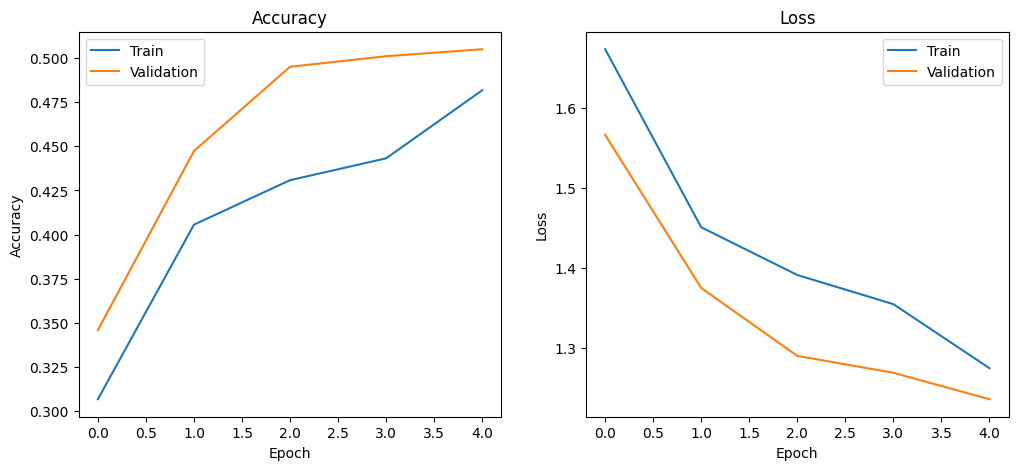

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

#### CONFUSION MATRIX

16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step


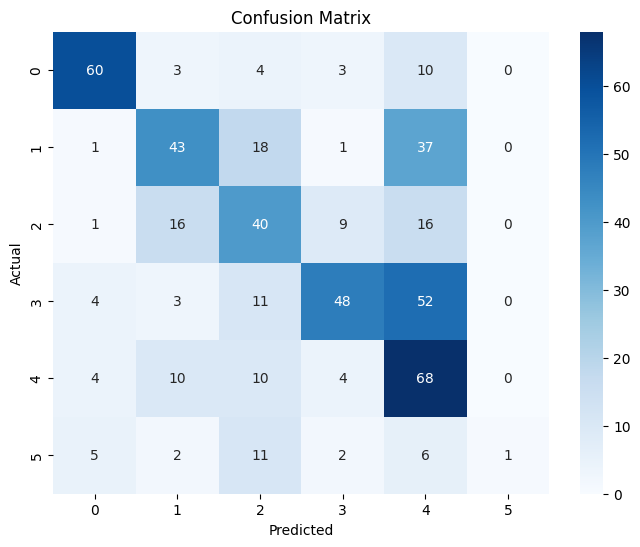

In [17]:
predictions = model.predict(val_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = val_generator.classes

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### CLASSIFICATION REPORT

In [18]:
class_names = list(
    train_generator.class_indices.keys()
)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   cardboard       0.80      0.75      0.77        80
       glass       0.56      0.43      0.49       100
       metal       0.43      0.49      0.45        82
       paper       0.72      0.41      0.52       118
     plastic       0.36      0.71      0.48        96
       trash       1.00      0.04      0.07        27

    accuracy                           0.52       503
   macro avg       0.64      0.47      0.46       503
weighted avg       0.60      0.52      0.51       503



#### SIMPAN MODEL

In [19]:
model.save("trash_classifier.h5")

print("Model berhasil disimpan")

Model berhasil disimpan


#### DOWNLOAD MODEL

In [20]:
from google.colab import files

files.download("trash_classifier.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### PREDIKSI GAMBAR BARU

In [31]:
from google.colab import files

uploaded = files.upload()

Saving Paper_sheet.jpg to Paper_sheet.jpg


In [33]:
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

classes = [
    'cardboard',
    'glass',
    'metal',
    'paper',
    'plastic',
    'trash'
]

index = np.argmax(prediction)

print("Prediksi :", classes[index])

print(
    "Confidence:",
    round(
        np.max(prediction)*100,
        2
    ),
    "%"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Prediksi : paper
Confidence: 45.65 %
